# 1. Import and Hardware Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset

import os
import random
import matplotlib.pyplot as plt
import numpy as np

!pip install tqdm -q
from tqdm.auto import tqdm

In [2]:
DATA_PATH = './data'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# 2. Hyperparamter

In [3]:
BATCH_SIZE = 128
IMG_SIZE = 128
IN_CHANNELS = 3

LR = 5e-4
EPOCHS = 100
SEED = 42
NUM_CLASSES = 50

LATENT_DIM = 512
ENCODER_CHANNELS = [32, 64, 128, 512]

# 3. Data Preparation

In [4]:
def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [5]:
train_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ]
)

# Apply seed
set_seed(SEED)
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

filtered_indices = [i for i, label in enumerate(dummy_data._labels) if label < NUM_CLASSES]

train_size = int(0.8 * len(filtered_indices))
val_size = len(filtered_indices) - train_size
split_generator = torch.Generator().manual_seed(SEED)

filtered_dummy_data = Subset(dummy_data, filtered_indices)
train_tmp_subset, val_tmp_subset = random_split(
    filtered_dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = [filtered_indices[i] for i in train_tmp_subset.indices]
val_indices = [filtered_indices[i] for i in val_tmp_subset.indices]

train_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=train_transform,
)

val_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=val_transform,
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)


dummy_test_dataset = datasets.Food101(root=DATA_PATH, split="test", download=True)
test_filterd_indices = [
    i for i, label in enumerate(dummy_test_dataset._labels) if label < NUM_CLASSES
]

test_dataset_full = datasets.Food101(
    root=DATA_PATH,
    split="test",
    download=False,
    transform=val_transform,
)
test_dataset = Subset(test_dataset_full, test_filterd_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)



100%|██████████| 5.00G/5.00G [05:07<00:00, 16.2MB/s] 


# 4. Model Architecture

In [6]:
class ConvBA(nn.Sequential):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=2,
        padding=1,
    ):
        super().__init__(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


class UpsampleConv(nn.Sequential):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
        scale_factor=2,
    ):
        super().__init__(
            nn.Upsample(
                scale_factor=scale_factor,
                mode="bilinear",
                align_corners=False,
            ),
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


class Autoencoder(nn.Module):
    def __init__(
        self,
        in_channels,
        img_size,
        encoder_channels,
        latent_dim,
    ):
        super().__init__()
        num_layers = len(encoder_channels)
        
        # The resolution of feature maps after decoder
        final_h = img_size // (2**num_layers)
        final_w = img_size // (2**num_layers)
        
        assert final_h >= 1 and final_w >= 1, "Too much downsamplings"
        
        # -------------------- Encoder --------------------
        encoder_layers = []
        curr_channels = in_channels
        
        for out_channels in encoder_channels:
            encoder_layers.append(
                ConvBA(
                    curr_channels,
                    out_channels,
                )
            )
            curr_channels = out_channels
        
        encoder_layers.extend(
            [
                nn.Flatten(),
                nn.Linear(curr_channels * final_h * final_w, latent_dim),
                nn.BatchNorm1d(latent_dim),
                nn.LeakyReLU(0.2, inplace=True),
            ]
        )
        self.encoder = nn.Sequential(*encoder_layers)
        
        # -------------------- Decoder --------------------
        decoder_layers = []
        decoder_layers.extend(
            [
                nn.Linear(latent_dim, curr_channels * final_h * final_w),
                nn.Unflatten(1, (curr_channels, final_h, final_w)),
            ]
        ),
        
        rev_channels = list(reversed(encoder_channels))
        for i in range(len(rev_channels) - 1):
            curr_channels = rev_channels[i]
            out_channels = rev_channels[i + 1]
            decoder_layers.append(
                UpsampleConv(curr_channels, out_channels)
            )
        
        decoder_layers.extend(
            [
                nn.Upsample(
                    scale_factor=2,
                    mode="bilinear",
                    align_corners=False,
                ),
                nn.Conv2d(
                    in_channels=rev_channels[-1],
                    out_channels=in_channels,
                    kernel_size=3,
                    padding=1,
                ),
                nn.Sigmoid(),
            ]
        )
        
        self.decoder = nn.Sequential(*decoder_layers)
    
    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent)

In [7]:
model = Autoencoder(
    in_channels=IN_CHANNELS,
    img_size=IMG_SIZE,
    encoder_channels=ENCODER_CHANNELS,
    latent_dim=LATENT_DIM,
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters()) / 1e6):.2f}M")

Total parameters: 34.96M


# 5. Train Preparation

In [8]:
class EarlyStopping:
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path

        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # 2. If the loss didnt decrease as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)



In [9]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)
scaler = torch.amp.GradScaler(device=device)

In [10]:
def train(model, loader, criterion, optimizer, scaler, noise_std=0.2):
    model.train()
    train_loss = 0.0
    loop = tqdm(loader, desc="Training", leave=False)
    
    for images, _ in loop:
        images = images.to(device)
        optimizer.zero_grad()

        noise = torch.randn_like(images) * noise_std
        noise_images = torch.clamp(images + noise, 0.0, 1.0)
        
        with torch.autocast(device_type=device.type):
            recontructed = model(noise_images)
            loss = criterion(recontructed, images)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.detach() * images.size(0)
    
    return train_loss.item() / len(loader.dataset)

def validate(model, loader, criterion, noise_std=0.2):
    model.eval()
    val_loss = 0.0
    loop = tqdm(loader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for images, _ in loop:
            images = images.to(device)
            noise = torch.randn_like(images) * noise_std
            noise_images = torch.clamp(images + noise, 0.0, 1.0)

            reconstructed = model(noise_images)
            loss = criterion(reconstructed, images)
            val_loss += loss.detach() * images.size(0)
    
    return val_loss.item() / len(loader.dataset)

# 6. Training

In [11]:
early_stopping = EarlyStopping(patience=5, save_path="best_ae_checkpoint.pth")
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train(model, train_loader, criterion, optimizer, scaler)
    val_loss = validate(model, val_loader, criterion)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Load best model for evaluation
model.load_state_dict(torch.load("best_ae_checkpoint.pth", weights_only=True, map_location=device))

Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 1/100: Train Loss: 0.021947 | Val Loss: 0.015942


Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

...

Epoch 99/100: Train Loss: 0.006829 | Val Loss: 0.006405


Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 100/100: Train Loss: 0.006844 | Val Loss: 0.006411
Early Stopping counter: 1 out of 5


<All keys matched successfully>

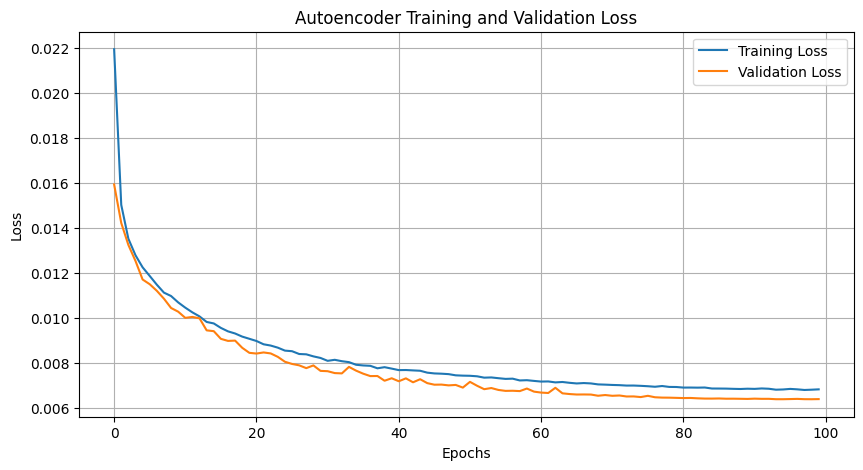

In [12]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



# 7. Results

Visualizing original vs reconstructed images...


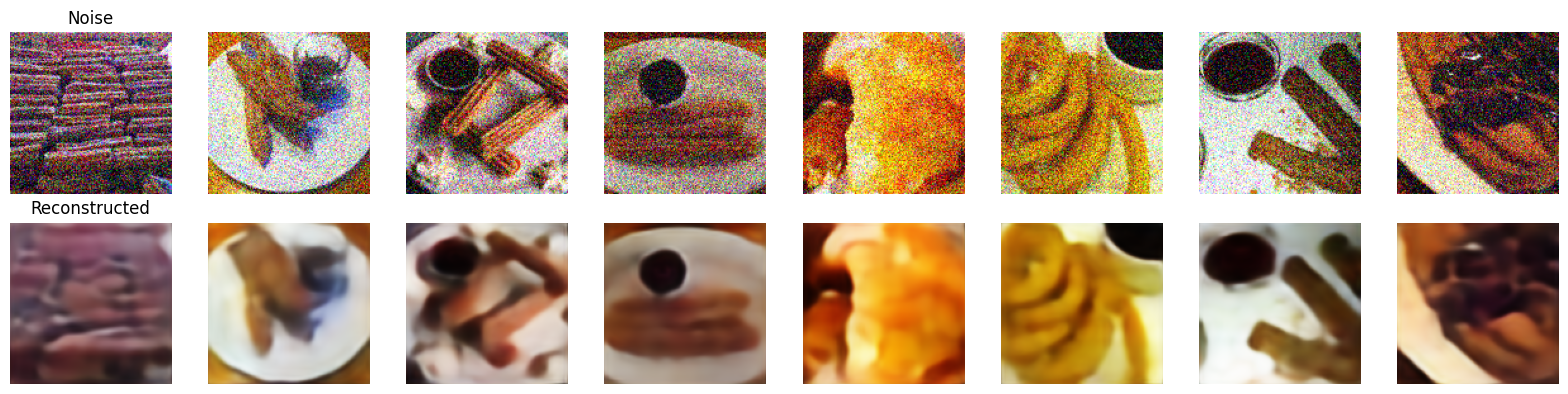

In [13]:
# Evaluation and Visualization
def visualize_reconstruction(model, test_loader, num_images=8, std_noise=0.2):
    model.eval()
    
    # Get a batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)
    noise = torch.randn_like(images) * std_noise
    noise_images = torch.clamp(images + noise, 0.0, 1.0)
    
    with torch.no_grad():
        reconstructed = model(noise_images)
        
    # Move images to CPU for visualization
    noise_images = noise_images.cpu()
    reconstructed = reconstructed.cpu()
    
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
    for i in range(num_images):
        # Original Image
        ax = axes[0, i]
        img = np.transpose(noise_images[i].numpy(), (1, 2, 0))
        ax.imshow(img)
        ax.axis('off')
        if i == 0:
            ax.set_title("Noise")
            
        # Reconstructed Image
        ax = axes[1, i]
        recon_img = np.transpose(reconstructed[i].numpy(), (1, 2, 0))
        ax.imshow(recon_img)
        ax.axis('off')
        if i == 0:
            ax.set_title("Reconstructed")
            
    plt.tight_layout()
    plt.show()

# Show results
print("Visualizing original vs reconstructed images...")
visualize_reconstruction(model, test_loader, num_images=8)

# 8. Latent Space Analysis (t-SNE)

Starting t-SNE with 600 filtered image from 6...


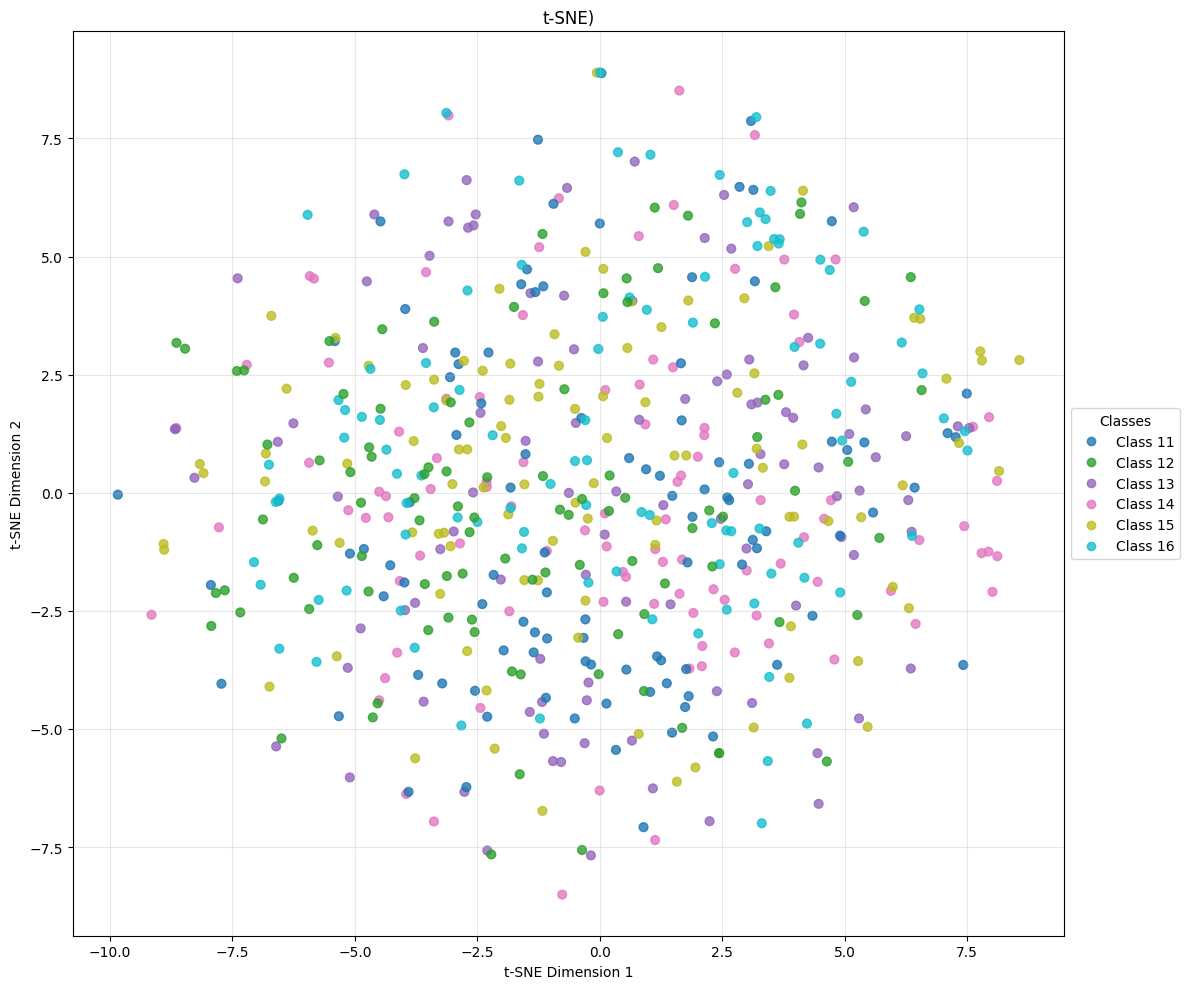

In [14]:
!pip install scikit-learn -q
from sklearn.manifold import TSNE


def visualize_tsne(
    model,
    dataloader,
    num_samples_per_class=100,
    target_classes=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
):
    model.eval()
    latents = []
    labels = []

    # Create a list of human-readable class names
    try:
        class_names = [dataloader.dataset.classes[i] for i in target_classes]
    except AttributeError:
        # Fallback
        class_names = [f"Class {i}" for i in target_classes]

    class_counts = {c: 0 for c in target_classes}

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            latent = model.encoder(images)
            latent = latent.view(latent.size(0), -1)

            # Filter the batch
            for i in range(len(targets)):
                target_idx = targets[i].item()
                if (
                    target_idx in target_classes
                    and class_counts[target_idx] < num_samples_per_class
                ):
                    latents.append(latent[i].cpu().numpy())
                    labels.append(target_classes.index(target_idx))
                    class_counts[target_idx] += 1

            if all(count >= num_samples_per_class for count in class_counts.values()):
                break

    latents = np.array(latents)
    labels = np.array(labels)

    print(f"Starting t-SNE with {len(latents)} filtered image from {len(target_classes)}...")
    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    latents_2d = tsne.fit_transform(latents)

    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(
        latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap="tab10", alpha=0.8, s=40
    )

    handles, _ = scatter.legend_elements(prop="colors")
    plt.legend(
        handles,
        class_names,
        title="Classes",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )

    plt.title("t-SNE)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


visualize_tsne(model, test_loader, target_classes=[11, 12, 13, 14, 15, 16])